In [3]:
import numpy as np


卷积神经网络（Convolutional Neural Network，CNN）常被用于图像识别、语音识别等各种场合。它在计算机视觉领域表现尤为出色，广泛应用于图像分类、目标检测、图像分割等任务。
卷积神经网络的灵感来自于动物视觉皮层组织的神经连接方式，单个神经元只对有限区域内的刺激作出反应，不同神经元的感知区域相互重叠从而覆盖整个视野。
CNN中新出现了卷积层（Convolution层）和池化层（Pooling层），下图是一个CNN的结构

卷积层用于提取输入数据的局部特征。


池化层用于降维，增强鲁棒性并防止过拟合。


全连接层用于整合特征并输出结果。

In [2]:
f = [2, 3, 5, 1, 6, 4, 3, 2, 5]
g = [1 / 3, 1 / 3, 1 / 3]
print(f)
print(g)

[2, 3, 5, 1, 6, 4, 3, 2, 5]
[0.3333333333333333, 0.3333333333333333, 0.3333333333333333]


In [4]:
# 离散序列的卷积运算
print(np.convolve(f, g))

[0.66666667 1.66666667 3.33333333 3.         4.         3.66666667
 4.33333333 3.         3.33333333 2.33333333 1.66666667]


# 卷积

🎯 CNN 是什么？
CNN = Convolutional Neural Network（卷积神经网络）
专门用来处理图像数据的神经网络，就像人眼识别物体一样。

🖼️ 核心思想：用"小窗口"看图片
传统神经网络的问题：
一张 1000×1000 的彩色图片
= 1000 × 1000 × 3 = 3,000,000 个像素

如果用全连接层：
输入层 300万节点 → 隐藏层 1000节点
参数量 = 300万 × 1000 = 30亿！💥

问题：
1. 参数太多，计算慢
2. 容易过拟合
3. 忽略了像素的空间关系

CNN:
不用看整张图，用"小窗口"（卷积核）滑动扫描

例如 3×3 的卷积核：
┌───┬───┬───┐
│ 1 │ 0 │-1 │  ← 这个3×3的小矩阵就是卷积核
├───┼───┼───┤
│ 1 │ 0 │-1 │     它在图片上滑动
├───┼───┼───┤
│ 1 │ 0 │-1 │     每次只看局部区域
└───┴───┴───┘

优势：
✅ 参数少（只有9个权重）
✅ 保留空间信息
✅ 能检测边缘、纹理等特征




CNN 的三大核心组件
1️⃣ 卷积层（Convolution） - 提取特征
# 你的代码中的卷积层
conv = nn.Conv2d(
    in_channels=3,      # 输入3个通道（RGB）
    out_channels=3,     # 输出3个通道（3个不同的卷积核）
    kernel_size=9,      # 卷积核大小 9×9
    stride=3,           # 步长：每次移动3个像素
    padding=0,          # 不填充
    bias=False          # 不用偏置
)
原始图片 (H, W, 3)
    ↓
卷积核滑动扫描
    ↓
提取特征（边缘、角点、纹理等）
    ↓
输出特征图 (H', W', 3)

每个卷积核学习一种特征：
- 卷积核1: 检测垂直边缘
- 卷积核2: 检测水平边缘
- 卷积核3: 检测对角线


输出高度 = (输入高度 - 卷积核大小 + 2×填充) / 步长 + 1
         = (H - 9 + 0) / 3 + 1
         = (H - 9) / 3 + 1

例如：输入 100×100
输出 = (100 - 9) / 3 + 1 = 31×31



2️⃣ 池化层（Pooling） - 降维

最大池化 (Max Pooling) 2×2:

输入 4×4:          输出 2×2:
┌───┬───┬───┬───┐   ┌───┬───┐
│ 1 │ 2 │ 3 │ 4 │   │ 6 │ 8 │  ← 取每个2×2区域的最大值
├───┼───┼───┼───┤   ├───┼───┤
│ 5 │ 6 │ 7 │ 8 │   │14 │16 │
├───┼───┼───┼───┤   └───┴───┘
│ 9 │10 │11 │12 │
├───┼───┼───┼───┤
│13 │14 │15 │16 │
└───┴───┴───┴───┘

作用：
✅ 减小数据量（4倍）
✅ 保留重要特征
✅ 提高鲁棒性（平移不变性）


3️⃣ 全连接层（Fully Connected） - 分类

卷积和池化提取的特征
    ↓
展平成一维向量
    ↓
全连接层分类
    ↓
输出类别概率

例如识别猫狗：
[0.9, 0.1] → 90%是猫，10%是狗


输入图片 (224×224×3)
    ↓
【卷积层】Conv3×3, 64个核 → (224×224×64)  提取低级特征（边缘）
    ↓
【激活函数】ReLU
    ↓
【池化层】MaxPool 2×2 → (112×112×64)     降维
    ↓
【卷积层】Conv3×3, 128个核 → (112×112×128) 提取中级特征（纹理）
    ↓
【激活函数】ReLU
    ↓
【池化层】MaxPool 2×2 → (56×56×128)
    ↓
【卷积层】Conv3×3, 256个核 → (56×56×256)  提取高级特征（形状）
    ↓
【激活函数】ReLU
    ↓
【池化层】MaxPool 2×2 → (28×28×256)
    ↓
【展平】Flatten → (200704,)
    ↓
【全连接层】FC 4096 → (4096,)
    ↓
【全连接层】FC 1000 → (1000,)  1000个类别
    ↓
【Softmax】输出概率分布


In [5]:
import torch
import matplotlib.pyplot as plt


图片数据形状： (1080, 1080, 3)
输入特征图形状： torch.Size([3, 1080, 1080])
输出特征图形状： torch.Size([3, 358, 358])


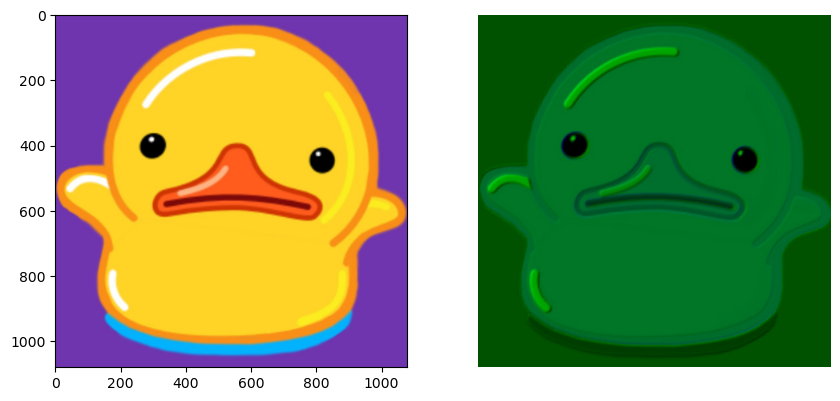

In [8]:
# 读取图片
img = plt.imread("../data/duck.jpg")
print("图片数据形状：", img.shape) # 图片数据形状： (1080, 1080, 3)

# 将图片数据转换为张量并改变形状
input = torch.tensor(img).permute(2, 0, 1).float()
print("输入特征图形状：", input.shape) # 输入特征图形状： torch.Size([3, 1080, 1080])

# 初始化卷积核
conv = torch.nn.Conv2d(in_channels=3, out_channels=3, kernel_size=9, stride=3, padding=0, bias=False)

# 对输入特征图进行卷积操作
# 前向传播，将卷积层应用到输入特征图上
output = conv(input)
#  形状计算 = (输入高度 - 卷积核大小 + 2×填充) / 步长 + 1
print("输出特征图形状：", output.shape) # 输出特征图形状： torch.Size([3, 358, 358])

# 将输出特征图转换为图片
output = torch.clamp(output.int(), 0, 255) # 限制输出在0到255之间
# 维度调整
output = output.permute(1, 2, 0).detach().numpy()
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img)
ax[1].imshow(output)
plt.axis("off")
plt.show()

In [ ]:
#